In [2]:
# Cell 1: Imports & settings
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# For data preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# For handling imbalanced data
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# For feature selection
from sklearn.feature_selection import chi2, mutual_info_classif, f_classif

# For models
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

# For evaluation
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, classification_report,
                             roc_auc_score, roc_curve)

# For saving model
import pickle
import joblib

print("All libraries imported successfully!")


All libraries imported successfully!


In [3]:
# Cell 2: Load dataset and basic EDA
print("\n" + "="*80)
print("STEP 2: LOADING DATASET")
print("="*80)

df = pd.read_csv('healthcare-dataset-stroke-data.csv')  # change path if needed

print(f"\nDataset Shape: {df.shape}")
print("\nFirst few rows:")
display(df.head())

print("\nDataset Info:")
display(df.info())

print("\nDataset Description:")
display(df.describe(include='all').T)

print("\nMissing Values:")
display(df.isnull().sum())

print("\nTarget Variable Distribution:")
display(df['stroke'].value_counts())
print("\nStroke Ratio:")
display(df['stroke'].value_counts(normalize=True))



STEP 2: LOADING DATASET

Dataset Shape: (5110, 12)

First few rows:


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


None


Dataset Description:


...

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64


Target Variable Distribution:


stroke
0    4861
1     249
Name: count, dtype: int64


Stroke Ratio:


stroke
0    0.951272
1    0.048728
Name: proportion, dtype: float64


STEP 3: INITIAL DATA PREPROCESSING (BEFORE SPLIT)
Removed 'id' column


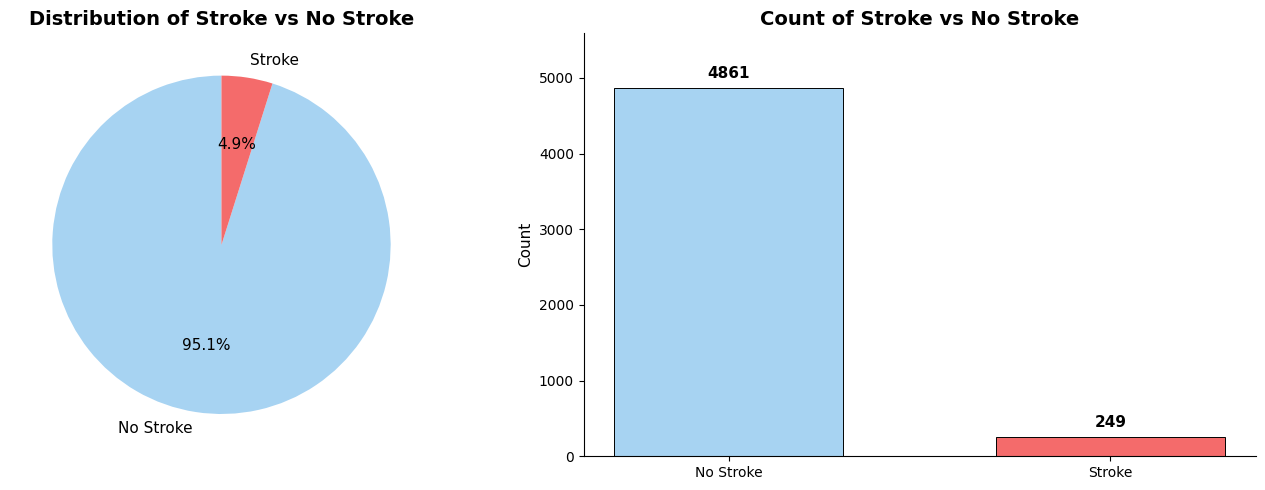


No Stroke: 4861, Stroke: 249
Class Imbalance Ratio: 19.52:1 (No Stroke : Stroke)


In [4]:
# ============================================================================
# STEP 3: INITIAL DATA PREPROCESSING (BEFORE SPLIT) — WITH PIE + BAR CHART
# ============================================================================
print("\n" + "="*80)
print("STEP 3: INITIAL DATA PREPROCESSING (BEFORE SPLIT)")
print("="*80)

# Remove 'id' column if present
if 'id' in df.columns:
    df.drop('id', axis=1, inplace=True)
    print("Removed 'id' column")

# Prepare data
counts = df['stroke'].value_counts().sort_index()  # 0 = No Stroke, 1 = Stroke
labels = ['No Stroke', 'Stroke']
colors = ['#a7d3f2', '#f46b6b']  # Light blue and red

# Create side-by-side plot: Pie (left) + Bar (right)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ------------------------ PIE CHART ------------------------
axes[0].pie(
    counts,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    textprops={'fontsize': 11, 'color': 'black'}
)
axes[0].set_title('Distribution of Stroke vs No Stroke', fontsize=14, fontweight='bold')

# ------------------------ BAR CHART ------------------------
bars = axes[1].bar(labels, counts, color=colors, width=0.6, edgecolor='black', linewidth=0.7)
axes[1].set_title('Count of Stroke vs No Stroke', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Count', fontsize=11)
axes[1].set_ylim(0, counts.max() * 1.15)

# Add count labels above bars
for bar in bars:
    height = bar.get_height()
    axes[1].text(
        bar.get_x() + bar.get_width() / 2, 
        height + counts.max() * 0.02, 
        f'{int(height)}', 
        ha='center', 
        va='bottom', 
        fontsize=11, 
        fontweight='bold'
    )

# Clean up chart style
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('target_distribution_original.png', dpi=300, bbox_inches='tight')
plt.show()

# Print imbalance info
ratio = counts[0] / counts[1] if 1 in counts else float('inf')
print(f"\nNo Stroke: {counts[0]}, Stroke: {counts[1]}")
print(f"Class Imbalance Ratio: {ratio:.2f}:1 (No Stroke : Stroke)")



STEP 3A: CORRELATION MAP OF FEATURES (Paper Figure 25 Style)


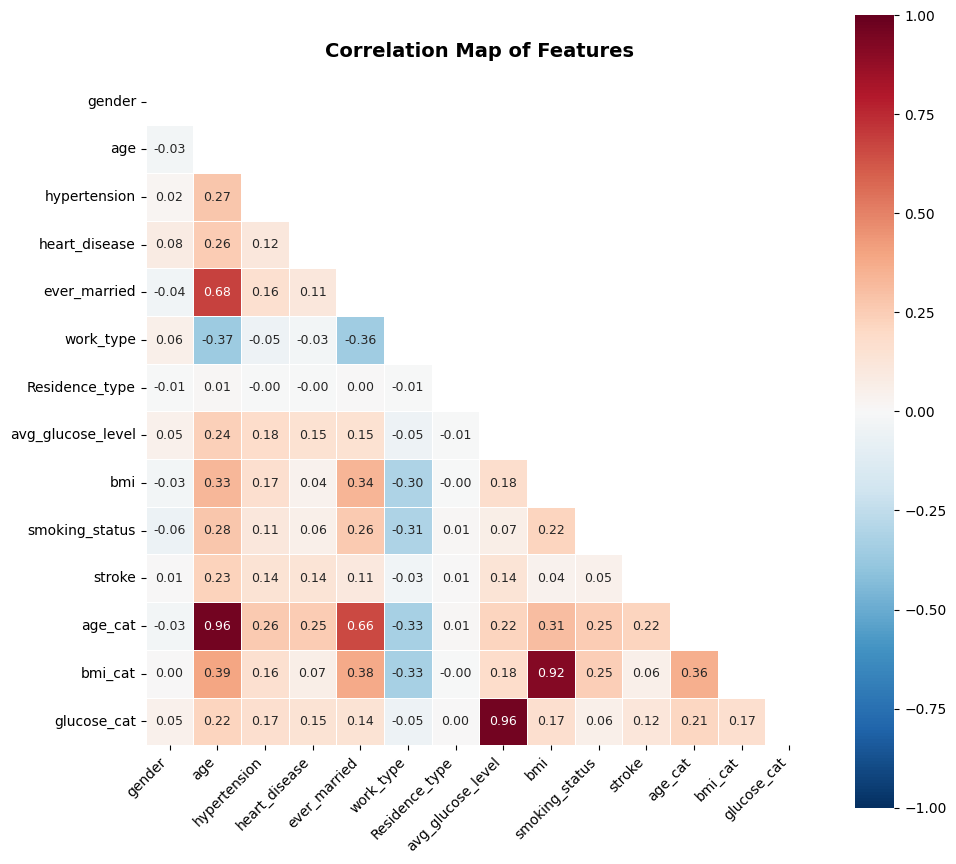

In [5]:
# ============================================================================
# STEP 3A: CORRELATION MAP OF FEATURES (Figure 25 from Base Paper)
# ============================================================================
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

print("\n" + "="*80)
print("STEP 3A: CORRELATION MAP OF FEATURES (Paper Figure 25 Style)")
print("="*80)

# Copy data so we don’t affect the main dataframe
corr_df = df.copy()

# --------------------------------------------------------------------
# Create category versions of age, glucose, and BMI (as in paper)
# --------------------------------------------------------------------
corr_df['age_cat'] = pd.cut(
    corr_df['age'],
    bins=[0, 20, 40, 60, 80, 120],
    labels=['0-20', '21-40', '41-60', '61-80', '80+']
).cat.codes

corr_df['bmi_cat'] = pd.cut(
    corr_df['bmi'],
    bins=[0, 18.5, 25, 30, 40, 100],
    labels=['Under', 'Normal', 'Overweight', 'Obese', 'Extreme']
).cat.codes

corr_df['glucose_cat'] = pd.cut(
    corr_df['avg_glucose_level'],
    bins=[0, 80, 120, 160, 200, 300],
    labels=['Low', 'Normal', 'High', 'Very High', 'Critical']
).cat.codes

# --------------------------------------------------------------------
# Encode categorical variables numerically for correlation
# --------------------------------------------------------------------
categorical_cols = corr_df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    corr_df[col] = LabelEncoder().fit_transform(corr_df[col].astype(str))

# Drop any remaining NaN values to avoid errors
corr_df = corr_df.dropna()

# --------------------------------------------------------------------
# Compute correlation matrix
# --------------------------------------------------------------------
corr_matrix = corr_df.corr()

# --------------------------------------------------------------------
# Mask the upper triangle for cleaner lower-triangle display
# --------------------------------------------------------------------
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# --------------------------------------------------------------------
# Plot correlation heatmap (same style as paper)
# --------------------------------------------------------------------
plt.figure(figsize=(10, 9))
sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap='RdBu_r',             # red-blue reversed (red = positive)
    annot=True,
    fmt='.2f',
    square=True,
    linewidths=0.6,
    cbar_kws={'label': ''},
    vmin=-1, vmax=1,
    annot_kws={"size": 9}
)
plt.title('Correlation Map of Features', fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('correlation_map_features.png', dpi=300, bbox_inches='tight')
plt.show()



STEP 3B: CLUSTERING OF FEATURES (Paper Figure 26 Style)


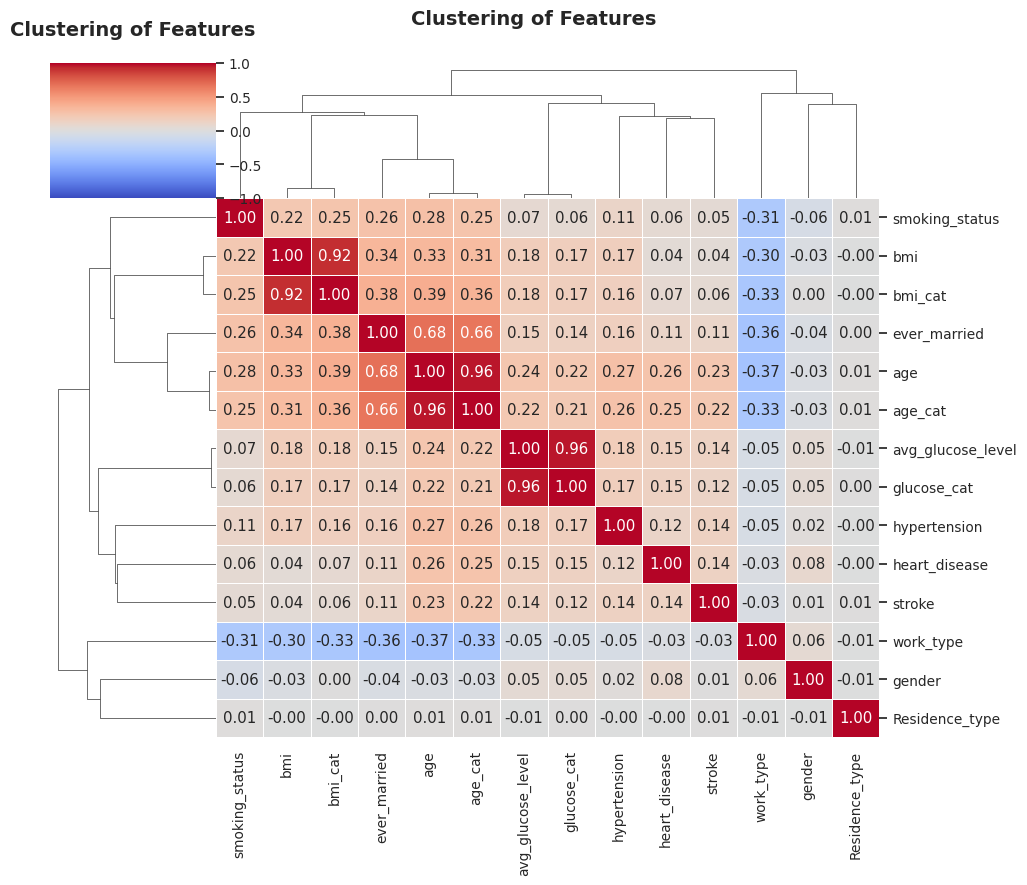

Clustering heatmap saved as 'clustering_of_features.png'


In [6]:
# ============================================================================
# STEP 3B: CLUSTERING OF FEATURES (Figure 26 from Base Paper)
# ============================================================================
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

print("\n" + "="*80)
print("STEP 3B: CLUSTERING OF FEATURES (Paper Figure 26 Style)")
print("="*80)

# Copy the dataset again to avoid modification
cluster_df = df.copy()

# -------------------------------------------------------------
# Create same engineered features used before
# -------------------------------------------------------------
cluster_df['age_cat'] = pd.cut(
    cluster_df['age'],
    bins=[0, 20, 40, 60, 80, 120],
    labels=['0–20', '21–40', '41–60', '61–80', '80+']
).cat.codes

cluster_df['bmi_cat'] = pd.cut(
    cluster_df['bmi'],
    bins=[0, 18.5, 25, 30, 40, 100],
    labels=['Under', 'Normal', 'Overweight', 'Obese', 'Extreme']
).cat.codes

# Optional: glucose_cat (paper figure 26 includes it)
cluster_df['glucose_cat'] = pd.cut(
    cluster_df['avg_glucose_level'],
    bins=[0, 80, 120, 160, 200, 300],
    labels=['Low', 'Normal', 'High', 'Very High', 'Critical']
).cat.codes

# -------------------------------------------------------------
# Encode categorical columns numerically
# -------------------------------------------------------------
for col in cluster_df.select_dtypes(include=['object']).columns:
    cluster_df[col] = LabelEncoder().fit_transform(cluster_df[col].astype(str))

# Drop NaNs for correlation
cluster_df = cluster_df.dropna()

# Compute correlation matrix
corr_matrix = cluster_df.corr()

# -------------------------------------------------------------
# Clustered heatmap using seaborn.clustermap
# -------------------------------------------------------------
sns.set(font_scale=0.9)
g = sns.clustermap(
    corr_matrix,
    cmap='coolwarm',          # red–blue style
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    figsize=(10, 9),
    vmin=-1, vmax=1,
    cbar_kws={'label': ''},
)

plt.title('Clustering of Features', fontsize=14, fontweight='bold', pad=20)
plt.subplots_adjust(top=0.92)
g.fig.suptitle('Clustering of Features', fontsize=14, fontweight='bold')
plt.savefig('clustering_of_features.png', dpi=300, bbox_inches='tight')
plt.show()

print("Clustering heatmap saved as 'clustering_of_features.png'")


In [7]:
# Cell 4: Train-test split (no leakage)
print("\n" + "="*80)
print("STEP 4: TRAIN-TEST SPLIT (NO DATA LEAKAGE)")
print("="*80)

X = df.drop('stroke', axis=1)
y = df['stroke']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")
print("\nTraining set stroke distribution:")
display(y_train.value_counts())
print("\nTest set stroke distribution:")
display(y_test.value_counts())



STEP 4: TRAIN-TEST SPLIT (NO DATA LEAKAGE)
Training set size: (4088, 10)
Test set size: (1022, 10)

Training set stroke distribution:


stroke
0    3889
1     199
Name: count, dtype: int64


Test set stroke distribution:


stroke
0    972
1     50
Name: count, dtype: int64

In [8]:
# Cell 5: Preprocessing training data only (missing values + label encoding)
print("\n" + "="*80)
print("STEP 5: PREPROCESSING TRAINING DATA")
print("="*80)

# Make copies
X_train_processed = X_train.copy()
X_test_processed = X_test.copy()

# 5.1 Handle missing values (bmi) using train mean
print("\nMissing values in training set (per column):")
display(X_train_processed.isnull().sum())

if 'bmi' in X_train_processed.columns:
    bmi_mean_train = X_train_processed['bmi'].mean()
    print(f"\nBMI mean from training data: {bmi_mean_train:.2f}")
    X_train_processed['bmi'].fillna(bmi_mean_train, inplace=True)
    X_test_processed['bmi'].fillna(bmi_mean_train, inplace=True)
else:
    bmi_mean_train = None
    print("\nNo 'bmi' column found; skipping BMI fill.")

print(f"\nTotal missing values after filling (train): {X_train_processed.isnull().sum().sum()}")

# 5.2 Label Encoding for categorical columns (fit on train only)
print("\nLabel Encoding (fit on train, transform on test)")
categorical_cols = X_train_processed.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical columns: {categorical_cols}")

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    X_train_processed[col] = le.fit_transform(X_train_processed[col].astype(str))
    # For test, handle unseen labels by mapping unknown to a new value
    X_test_processed[col] = X_test_processed[col].astype(str).map(lambda x: x if x in le.classes_ else None)
    # If any None (unseen), add to classes_ and transform
    # Create a safe transform:
    # Build mapping dict
    mapping = {cls: i for i, cls in enumerate(le.classes_)}
    # unseen -> len(mapping)
    X_test_processed[col] = X_test_processed[col].apply(lambda x: mapping[x] if x in mapping else len(mapping))
    label_encoders[col] = le
    print(f"{col} encoder classes: {list(le.classes_)}")

# Save label encoders
with open('label_encoders.pkl', 'wb') as f:
    pickle.dump(label_encoders, f)
print("Label encoders saved to 'label_encoders.pkl'")



STEP 5: PREPROCESSING TRAINING DATA

Missing values in training set (per column):


gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  170
smoking_status         0
dtype: int64


BMI mean from training data: 28.92

Total missing values after filling (train): 0

Label Encoding (fit on train, transform on test)
Categorical columns: ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
gender encoder classes: ['Female', 'Male', 'Other']
ever_married encoder classes: ['No', 'Yes']
work_type encoder classes: ['Govt_job', 'Never_worked', 'Private', 'Self-employed', 'children']
Residence_type encoder classes: ['Rural', 'Urban']
smoking_status encoder classes: ['Unknown', 'formerly smoked', 'never smoked', 'smokes']
Label encoders saved to 'label_encoders.pkl'


In [9]:
# ============================================================================
# STEP 6: FEATURE ENGINEERING (Based on Base Paper Section F)
# ============================================================================

print("\n" + "="*80)
print("STEP 6: FEATURE ENGINEERING (Based on Paper’s Guidelines)")
print("="*80)

# Copy data
X_train_fe = X_train_processed.copy()
X_test_fe = X_test_processed.copy()

# --- Categorical ordering (encode stroke-risk order) ---
# Each ordered list follows paper priority (low→high risk)

categorical_order = {
    'gender': ['female', 'male'],
    'hypertension': ['0', '1'],
    'heart_disease': ['0', '1'],
    'ever_married': ['No', 'Yes'],
    'work_type': ['children', 'Govt_job', 'Self-employed', 'Private'],
    'Residence_type': ['Rural', 'Urban'],
    'smoking_status': ['smokes', 'formerly smoked', 'never smoked']
}

for col, order in categorical_order.items():
    if col in X_train_fe.columns:
        cat_type = pd.CategoricalDtype(categories=order, ordered=True)
        X_train_fe[col] = X_train_fe[col].astype(cat_type).cat.codes
        X_test_fe[col] = X_test_fe[col].astype(cat_type).cat.codes

print("Categorical feature ordering encoded successfully!")

# --- Numeric feature clipping to domain ranges ---
range_limits = {
    'age': (55, 80),
    'avg_glucose_level': (80, 200),
    'bmi': (20, 40)
}

for col, (low, high) in range_limits.items():
    if col in X_train_fe.columns:
        X_train_fe[col] = X_train_fe[col].clip(lower=low, upper=high)
        X_test_fe[col] = X_test_fe[col].clip(lower=low, upper=high)

print("Numeric features clipped to medically relevant ranges!")

# --- Replace processed data ---
X_train_processed = X_train_fe.copy()
X_test_processed = X_test_fe.copy()

print("\nFeature engineering completed based on base paper Section F.")



STEP 6: FEATURE ENGINEERING (Based on Paper’s Guidelines)
Categorical feature ordering encoded successfully!
Numeric features clipped to medically relevant ranges!

Feature engineering completed based on base paper Section F.



STEP 7: HANDLING CLASS IMBALANCE (TRAINING DATA ONLY)

Before balancing:


Training - Class 0: 3889, Class 1: 199

After under-sampling:
Class 0: 1990, Class 1: 199

After SMOTE (balanced):
Class 0: 1990, Class 1: 1990


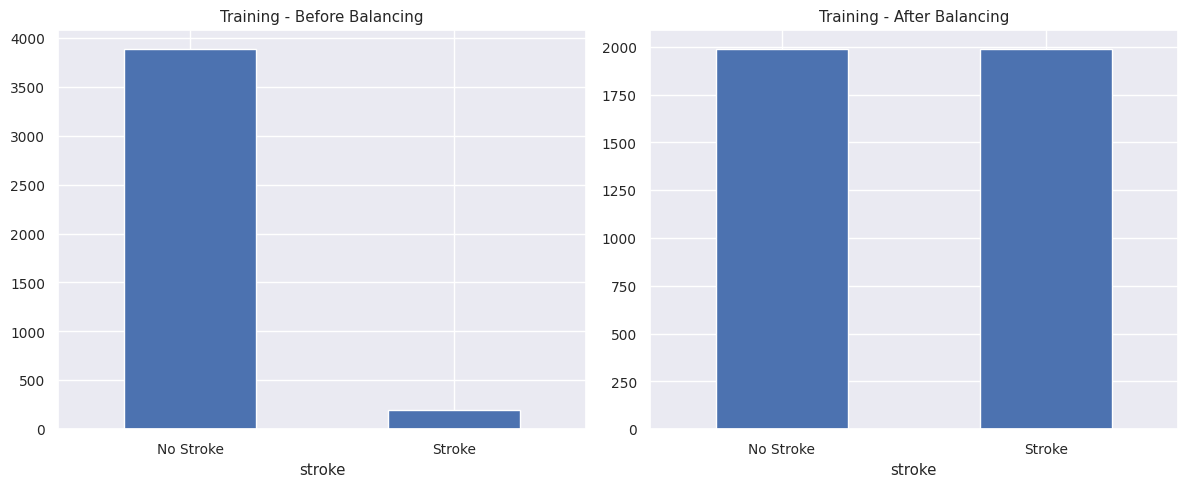

In [10]:
# Cell 7: Handling class imbalance on training data (under-sample then SMOTE)
print("\n" + "="*80)
print("STEP 7: HANDLING CLASS IMBALANCE (TRAINING DATA ONLY)")
print("="*80)

print("\nBefore balancing:")
print(f"Training - Class 0: {(y_train == 0).sum()}, Class 1: {(y_train == 1).sum()}")

# Under-sample majority class
under_sampler = RandomUnderSampler(sampling_strategy=0.1, random_state=42)
X_train_under, y_train_under = under_sampler.fit_resample(X_train_processed, y_train)

print("\nAfter under-sampling:")
print(f"Class 0: {(y_train_under == 0).sum()}, Class 1: {(y_train_under == 1).sum()}")

# SMOTE over-sampling
smote = SMOTE(sampling_strategy=1.0, random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_under, y_train_under)

print("\nAfter SMOTE (balanced):")
print(f"Class 0: {(y_train_balanced == 0).sum()}, Class 1: {(y_train_balanced == 1).sum()}")

# Visualize before vs after
fig, axes = plt.subplots(1, 2, figsize=(12,5))
pd.Series(y_train).value_counts().plot(kind='bar', ax=axes[0])
axes[0].set_title('Training - Before Balancing')
axes[0].set_xticklabels(['No Stroke','Stroke'], rotation=0)
pd.Series(y_train_balanced).value_counts().plot(kind='bar', ax=axes[1])
axes[1].set_title('Training - After Balancing')
axes[1].set_xticklabels(['No Stroke','Stroke'], rotation=0)
plt.tight_layout()
plt.savefig('data_balancing.png', dpi=300, bbox_inches='tight')
plt.show()



STEP 8: FEATURE SELECTION (Mutual Info, Chi2, ANOVA — Base Paper, Fixed)


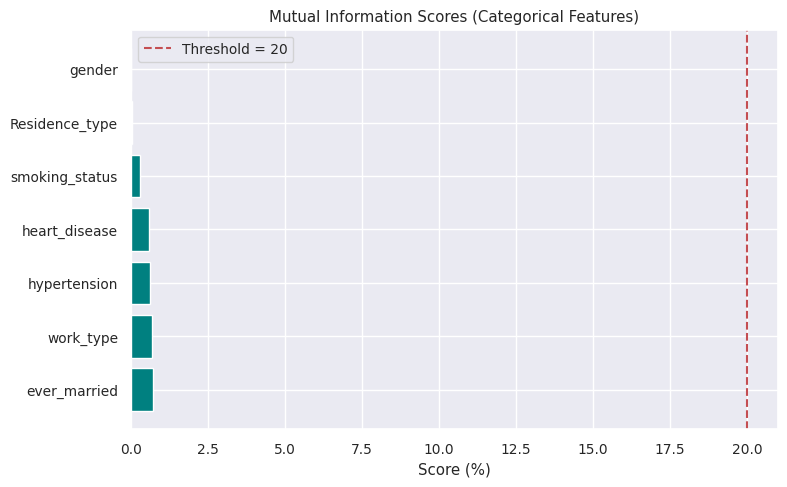


Mutual Information Scores:
          Feature  MI_Score
3    ever_married  0.694978
4       work_type  0.682543
1    hypertension  0.597570
2   heart_disease  0.589683
6  smoking_status  0.275049
5  Residence_type  0.011965
0          gender  0.005083

Rejected (MI < 20): ['ever_married', 'work_type', 'hypertension', 'heart_disease', 'smoking_status', 'Residence_type', 'gender']


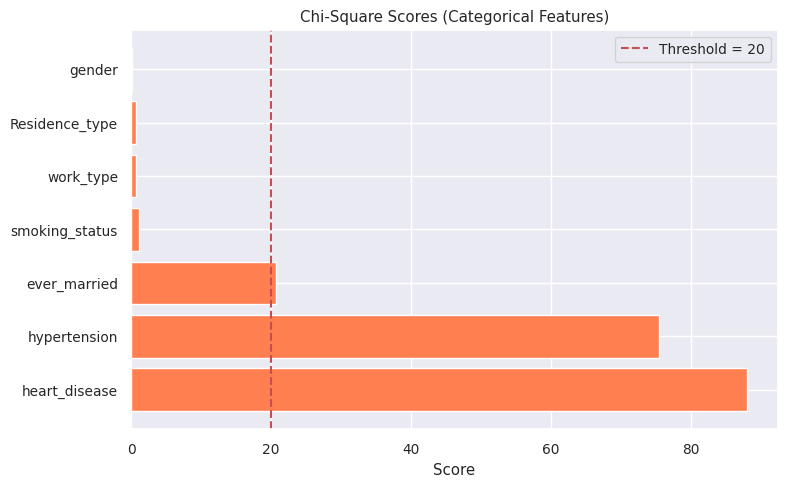


Chi-Square Scores:
          Feature  Chi2_Score
2   heart_disease   87.987436
1    hypertension   75.449498
3    ever_married   20.622787
6  smoking_status    1.123141
4       work_type    0.731475
5  Residence_type    0.600717
0          gender    0.119500


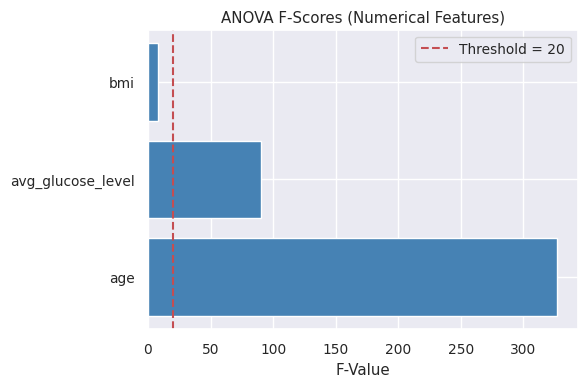


ANOVA Scores:
             Feature  ANOVA_Score
0                age   326.916568
1  avg_glucose_level    90.503870
2                bmi     7.759776

Rejected (ANOVA < 20): ['bmi']

Feature selection analysis completed (MI / Chi2 / ANOVA shown above).
However, keeping ALL features for model training and testing (no rejection).
Number of features to be used for modeling: 10
['gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status']


In [11]:
# ============================================================================
# STEP 8: FEATURE SELECTION (Mutual Info, Chi2, ANOVA — Base Paper, Fixed)
# ============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_classif, chi2, f_classif
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

print("\n" + "="*80)
print("STEP 8: FEATURE SELECTION (Mutual Info, Chi2, ANOVA — Base Paper, Fixed)")
print("="*80)

# --------------------------------------------------------------------------
# Prepare data
# --------------------------------------------------------------------------
fs_df = df.copy()

# Encode categorical variables
for col in fs_df.select_dtypes(include=['object']).columns:
    fs_df[col] = LabelEncoder().fit_transform(fs_df[col].astype(str))

# Handle NaNs (fill with column mean for numerical features)
for col in fs_df.columns:
    if fs_df[col].dtype in [np.float64, np.int64]:
        fs_df[col].fillna(fs_df[col].mean(), inplace=True)

# Split features and target
X = fs_df.drop(columns=['stroke'])
y = fs_df['stroke']

# --------------------------------------------------------------------------
# Separate categorical and numeric columns
# --------------------------------------------------------------------------
cat_cols = X.select_dtypes(include=['int64', 'int32', 'uint8']).columns.tolist()
num_cols = ['age', 'avg_glucose_level', 'bmi']  # Only continuous features

# --------------------------------------------------------------------------
# MUTUAL INFORMATION
# --------------------------------------------------------------------------
mi_scores = mutual_info_classif(X[cat_cols], y, discrete_features=True, random_state=42)
mi_df = pd.DataFrame({'Feature': cat_cols, 'MI_Score': mi_scores * 100}).sort_values('MI_Score', ascending=False)

plt.figure(figsize=(8,5))
plt.barh(mi_df['Feature'], mi_df['MI_Score'], color='teal')
plt.axvline(x=20, color='r', linestyle='--', label='Threshold = 20')
plt.title('Mutual Information Scores (Categorical Features)')
plt.xlabel('Score (%)')
plt.legend()
plt.tight_layout()
plt.show()

print("\nMutual Information Scores:")
print(mi_df)

mi_reject = mi_df[mi_df['MI_Score'] < 20]['Feature'].tolist()
print(f"\nRejected (MI < 20): {mi_reject}")

# --------------------------------------------------------------------------
# CHI-SQUARE TEST
# --------------------------------------------------------------------------
scaler = MinMaxScaler()
X_chi2 = scaler.fit_transform(X[cat_cols])
chi2_scores, _ = chi2(X_chi2, y)
chi_df = pd.DataFrame({'Feature': cat_cols, 'Chi2_Score': chi2_scores}).sort_values('Chi2_Score', ascending=False)

plt.figure(figsize=(8,5))
plt.barh(chi_df['Feature'], chi_df['Chi2_Score'], color='coral')
plt.axvline(x=20, color='r', linestyle='--', label='Threshold = 20')
plt.title('Chi-Square Scores (Categorical Features)')
plt.xlabel('Score')
plt.legend()
plt.tight_layout()
plt.show()

print("\nChi-Square Scores:")
print(chi_df)

# --------------------------------------------------------------------------
# ANOVA F-TEST (Numerical)
# --------------------------------------------------------------------------
X_anova = X[num_cols].apply(pd.to_numeric, errors='coerce').fillna(X[num_cols].mean())

anova_scores, _ = f_classif(X_anova, y)
anova_df = pd.DataFrame({'Feature': num_cols, 'ANOVA_Score': anova_scores}).sort_values('ANOVA_Score', ascending=False)

plt.figure(figsize=(6,4))
plt.barh(anova_df['Feature'], anova_df['ANOVA_Score'], color='steelblue')
plt.axvline(x=20, color='r', linestyle='--', label='Threshold = 20')
plt.title('ANOVA F-Scores (Numerical Features)')
plt.xlabel('F-Value')
plt.legend()
plt.tight_layout()
plt.show()

print("\nANOVA Scores:")
print(anova_df)

anova_reject = anova_df[anova_df['ANOVA_Score'] < 20]['Feature'].tolist()
print(f"\nRejected (ANOVA < 20): {anova_reject}")

# --------------------------------------------------------------------------
# FINAL SELECTION DECISION — KEEP ALL FEATURES (analysis only)
# --------------------------------------------------------------------------
# Note: We performed MI / Chi2 / ANOVA above for analysis/visualization.
# Per your choice, DO NOT drop any features — use them all for modeling.

# Keep ALL features for modeling/training/testing
selected_features = X.columns.tolist()

print("\nFeature selection analysis completed (MI / Chi2 / ANOVA shown above).")
print("However, keeping ALL features for model training and testing (no rejection).")
print(f"Number of features to be used for modeling: {len(selected_features)}")
print(selected_features)



In [12]:
# Cell 9: Feature scaling (StandardScaler) — uses selected_features
print("\n" + "="*80)
print("STEP 9: FEATURE SCALING")
print("="*80)

# Ensure 'selected_features' exists (will be list of features to use)
try:
    selected_features
except NameError:
    # fallback: use all columns from X_train_balanced
    selected_features = X_train_balanced.columns.tolist()
    print("Note: 'selected_features' was not defined. Falling back to X_train_balanced.columns.")

# Make sure train and test contain all selected features
for c in selected_features:
    if c not in X_train_balanced.columns:
        X_train_balanced[c] = 0
    if c not in X_test_processed.columns:
        X_test_processed[c] = 0

# Reorder columns to the same order everywhere
X_train_balanced = X_train_balanced[selected_features].copy()
X_test_processed = X_test_processed[selected_features].copy()

# Convert all to numeric (safe) and fill remaining NaNs with training means
X_train_balanced = X_train_balanced.apply(pd.to_numeric, errors='coerce')
X_test_processed = X_test_processed.apply(pd.to_numeric, errors='coerce')

# Fill NaNs in train with column mean, and in test with train mean
train_means = X_train_balanced.mean()
X_train_balanced = X_train_balanced.fillna(train_means)
X_test_processed = X_test_processed.fillna(train_means)

# Standard scaling (fit on training only)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_balanced)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=selected_features, index=X_train_balanced.index)

X_test_scaled = scaler.transform(X_test_processed)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=selected_features, index=X_test_processed.index)

print("Feature scaling completed!")
print(f"Training data shape after scaling: {X_train_scaled.shape}")
print(f"Test data shape after scaling:     {X_test_scaled.shape}")

joblib.dump(scaler, 'scaler.pkl')
print("Scaler saved to 'scaler.pkl'")




STEP 9: FEATURE SCALING
Feature scaling completed!
Training data shape after scaling: (3980, 10)
Test data shape after scaling:     (1022, 10)
Scaler saved to 'scaler.pkl'


In [13]:
# Cell 10: Model training with 5-Fold CV (keeps test-set eval + later steps working)
print("\n" + "="*80)
print("STEP 10: MODEL TRAINING WITH 5-FOLD CROSS-VALIDATION")
print("="*80)

from sklearn.model_selection import StratifiedKFold, cross_validate

models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Support Vector Machine': SVC(probability=True, random_state=42),
    'Naive Bayes': GaussianNB()
}

trained_models = {}
results = []            # will store TEST-set metrics (for Step 11/12 compatibility)
cv_rows = []            # will store CV mean metrics (extra, saved separately)

# Ensure y_train_balanced and y_test exist
if 'y_train_balanced' not in globals():
    raise RuntimeError("y_train_balanced not found. Run the balancing step (SMOTE/under-sampling).")
if 'y_test' not in globals():
    raise RuntimeError("y_test not found. Make sure you did train_test_split earlier.")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    print(f"\n{'-'*60}\nTraining with 5-Fold CV: {name}\n{'-'*60}")

    # ---- 5-Fold Cross-Validation on the TRAINING data ----
    scores = cross_validate(
        model,
        X_train_scaled,
        y_train_balanced,
        cv=cv,
        scoring=['accuracy','precision','recall','f1'],
        return_estimator=True,
        n_jobs=-1
    )

    cv_acc = scores['test_accuracy'].mean()
    cv_pre = scores['test_precision'].mean()
    cv_rec = scores['test_recall'].mean()
    cv_f1  = scores['test_f1'].mean()

    print(f"CV Mean Accuracy:  {cv_acc:.4f}")
    print(f"CV Mean Precision: {cv_pre:.4f}")
    print(f"CV Mean Recall:    {cv_rec:.4f}")
    print(f"CV Mean F1 Score:  {cv_f1:.4f}")

    cv_rows.append({
        'Model': name,
        'CV_Accuracy': cv_acc,
        'CV_Precision': cv_pre,
        'CV_Recall': cv_rec,
        'CV_F1': cv_f1
    })

    # ---- Fit on FULL training data (so later steps can use trained_models) ----
    model.fit(X_train_scaled, y_train_balanced)
    trained_models[name] = model

    # ---- Evaluate on the HOLDOUT test set (keeps your original outputs) ----
    y_pred = model.predict(X_test_scaled)

    # probability-like scores (for later ROC, etc.)
    if hasattr(model, 'predict_proba'):
        try:
            y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
        except Exception:
            y_pred_proba = None
    else:
        try:
            scores_dec = model.decision_function(X_test_scaled)
            y_pred_proba = (scores_dec - scores_dec.min()) / (scores_dec.max() - scores_dec.min())
        except Exception:
            y_pred_proba = None

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    results.append({
        'Model': name,
        'Accuracy': accuracy,          # TEST metrics (used by Step 11/12)
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    })

    print(f"\nTest Set -> Accuracy: {accuracy:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f} | F1: {f1:.4f}")
    print("Confusion Matrix:")
    display(confusion_matrix(y_test, y_pred))

# Save results (test-set) for Step 11
results_df = pd.DataFrame(results).sort_values('Accuracy', ascending=False)
results_df.to_csv('model_comparison_results.csv', index=False)
print("\nSaved test-set model comparison to 'model_comparison_results.csv'")

# Save CV means separately (extra file)
cv_results_df = pd.DataFrame(cv_rows).sort_values('CV_F1', ascending=False)
cv_results_df.to_csv('cv_results_5fold.csv', index=False)
print("Saved 5-Fold CV mean scores to 'cv_results_5fold.csv'")
display(cv_results_df)



STEP 10: MODEL TRAINING WITH 5-FOLD CROSS-VALIDATION

------------------------------------------------------------
Training with 5-Fold CV: Random Forest
------------------------------------------------------------


CV Mean Accuracy:  0.8781
CV Mean Precision: 0.8549
CV Mean Recall:    0.9111
CV Mean F1 Score:  0.8820

Test Set -> Accuracy: 0.8513 | Precision: 0.1458 | Recall: 0.4200 | F1: 0.2165
Confusion Matrix:


array([[849, 123],
       [ 29,  21]])


------------------------------------------------------------
Training with 5-Fold CV: XGBoost
------------------------------------------------------------
CV Mean Accuracy:  0.8922
CV Mean Precision: 0.8844
CV Mean Recall:    0.9025
CV Mean F1 Score:  0.8933

Test Set -> Accuracy: 0.8708 | Precision: 0.1204 | Recall: 0.2600 | F1: 0.1646
Confusion Matrix:


array([[877,  95],
       [ 37,  13]])

...

array([[708, 264],
       [ 12,  38]])


------------------------------------------------------------
Training with 5-Fold CV: Naive Bayes
------------------------------------------------------------
CV Mean Accuracy:  0.7445
CV Mean Precision: 0.7595
CV Mean Recall:    0.7161
CV Mean F1 Score:  0.7370

Test Set -> Accuracy: 0.7984 | Precision: 0.1609 | Recall: 0.7400 | F1: 0.2643
Confusion Matrix:


array([[779, 193],
       [ 13,  37]])


Saved test-set model comparison to 'model_comparison_results.csv'
Saved 5-Fold CV mean scores to 'cv_results_5fold.csv'


,Model,CV_Accuracy,CV_Precision,CV_Recall,CV_F1
1,XGBoost,0.892211,0.884369,0.902513,0.893287
0,Random Forest,0.878141,0.854947,0.911055,0.881968
3,K-Nearest Neighbors,0.832161,0.793037,0.899497,0.842777
4,Support Vector Machine,0.756784,0.739115,0.794472,0.765541
5,Naive Bayes,0.744472,0.759546,0.716080,0.736961
2,Logistic Regression,0.746734,0.768692,0.706533,0.736164



STEP 11: MODEL EVALUATION AND COMPARISON


,Model,Accuracy,Precision,Recall,F1-Score
0,XGBoost,0.870841,0.120370,0.26,0.164557
1,Random Forest,0.851272,0.145833,0.42,0.216495
2,Logistic Regression,0.802348,0.169565,0.78,0.278571
3,Naive Bayes,0.798434,0.160870,0.74,0.264286
4,K-Nearest Neighbors,0.781800,0.138075,0.66,0.228374
5,Support Vector Machine,0.729941,0.125828,0.76,0.215909


Results saved to 'model_comparison_results.csv'


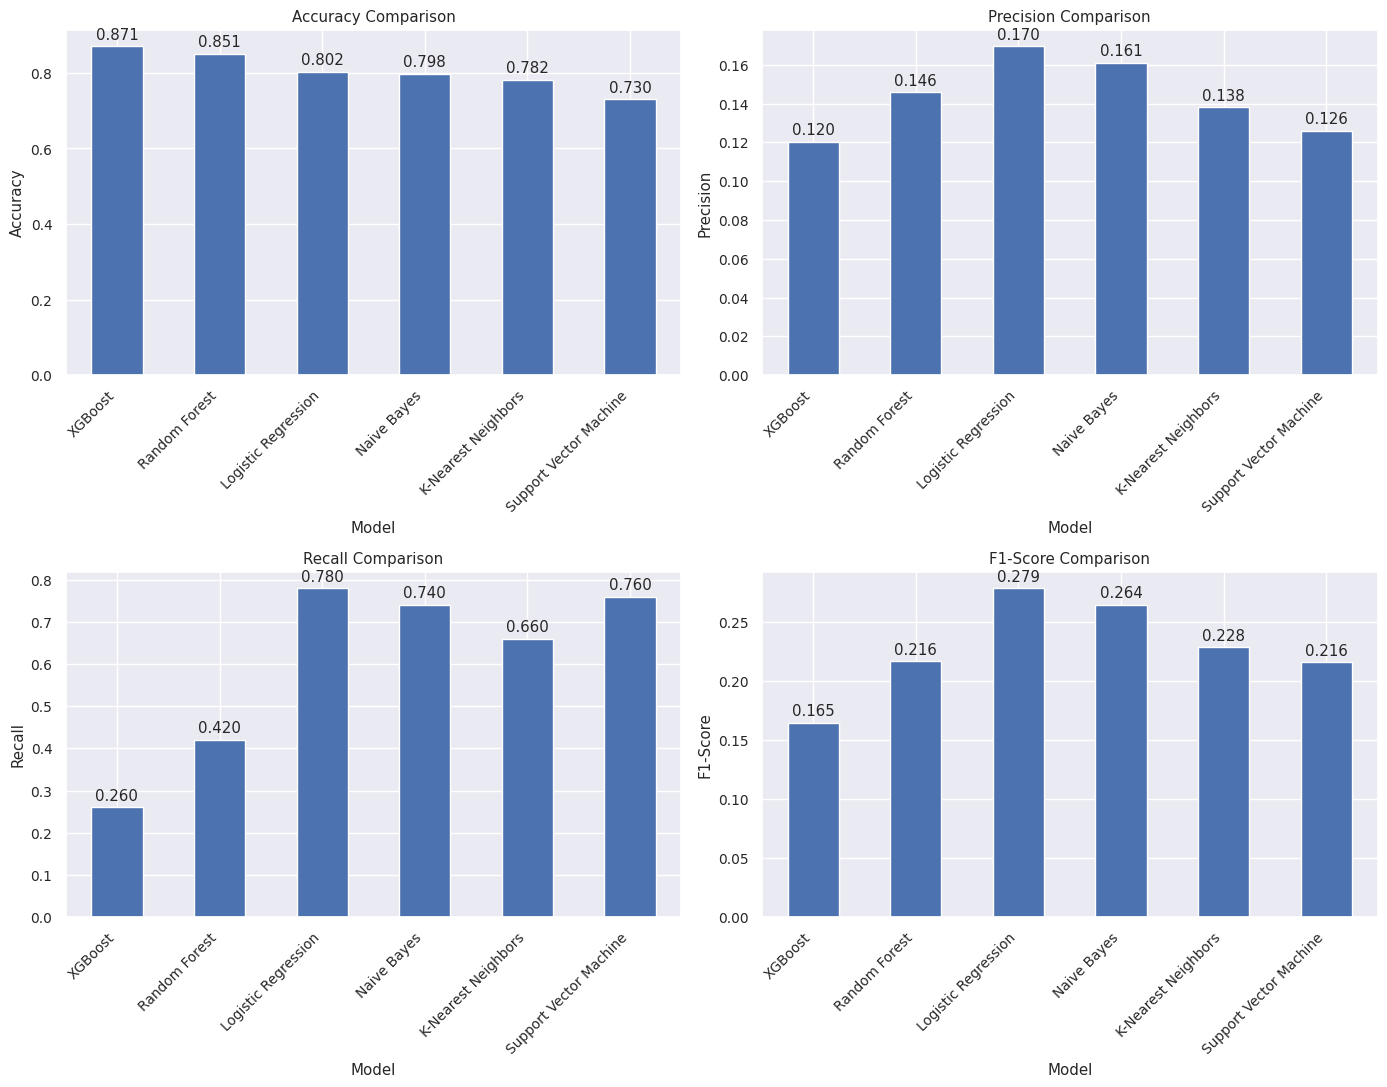

In [14]:
# Cell 11: Evaluation & comparison across models (summary + plots) - robust
print("\n" + "="*80)
print("STEP 11: MODEL EVALUATION AND COMPARISON")
print("="*80)

# Build results_df from results if not already present
if 'results_df' not in globals():
    results_df = pd.DataFrame(results) if len(results) > 0 else pd.DataFrame(columns=['Model','Accuracy','Precision','Recall','F1-Score'])

if results_df.empty:
    print("Warning: results_df is empty. No model results to display.")
else:
    # sort (descending accuracy)
    results_df = results_df.sort_values('Accuracy', ascending=False).reset_index(drop=True)
    display(results_df)

    # save
    results_df.to_csv('model_comparison_results.csv', index=False)
    print("Results saved to 'model_comparison_results.csv'")

    # Plot metrics
    fig, axes = plt.subplots(2, 2, figsize=(14,11))
    metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
    for idx, metric in enumerate(metrics):
        ax = axes[idx//2, idx%2]
        # safe plotting if column exists
        if metric in results_df.columns and not results_df.empty:
            results_df.plot(x='Model', y=metric, kind='bar', ax=ax, legend=False)
            ax.set_title(f'{metric} Comparison')
            ax.set_xlabel('Model')
            ax.set_ylabel(metric)
            ax.set_xticklabels(results_df['Model'], rotation=45, ha='right')
            for container in ax.containers:
                ax.bar_label(container, fmt='%.3f', padding=3)
        else:
            ax.text(0.5, 0.5, f"No {metric} data", ha='center')
            ax.set_axis_off()
    plt.tight_layout()
    plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()



STEP 12: DETAILED EVALUATION OF BEST MODEL
Best Model: XGBoost (by Accuracy)

Classification Report:
              precision    recall  f1-score   support

   No Stroke       0.96      0.90      0.93       972
      Stroke       0.12      0.26      0.16        50

    accuracy                           0.87      1022
   macro avg       0.54      0.58      0.55      1022
weighted avg       0.92      0.87      0.89      1022



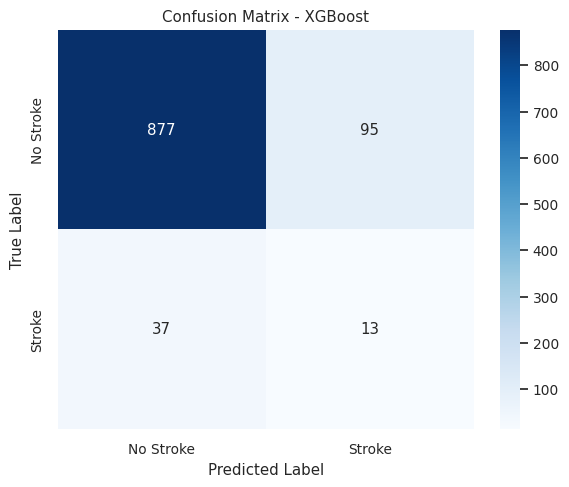

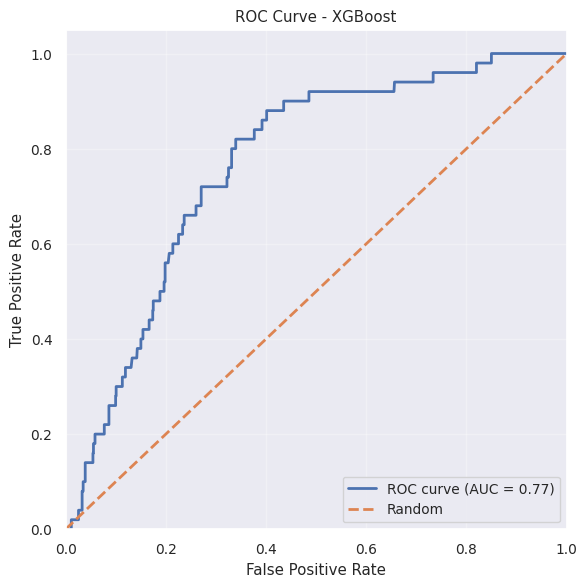


ROC-AUC Score: 0.7668


In [15]:
# Cell 12: Detailed evaluation of best model (classification report, confusion, ROC)
print("\n" + "="*80)
print("STEP 12: DETAILED EVALUATION OF BEST MODEL")
print("="*80)

if 'results_df' not in globals() or results_df.empty:
    raise RuntimeError("No results available to pick best model. Run training first.")

best_model_name = results_df.iloc[0]['Model']
if best_model_name not in trained_models:
    raise KeyError(f"Best model '{best_model_name}' not found in trained_models. Available: {list(trained_models.keys())}")

best_model = trained_models[best_model_name]
print(f"Best Model: {best_model_name} (by Accuracy)")

# Predictions & probabilities (safe)
y_pred_best = best_model.predict(X_test_scaled)
y_pred_proba_best = None
if hasattr(best_model, 'predict_proba'):
    try:
        y_pred_proba_best = best_model.predict_proba(X_test_scaled)[:, 1]
    except Exception:
        y_pred_proba_best = None
else:
    try:
        y_scores = best_model.decision_function(X_test_scaled)
        y_pred_proba_best = (y_scores - y_scores.min()) / (y_scores.max() - y_scores.min())
    except Exception:
        y_pred_proba_best = None

print("\nClassification Report:")
print(classification_report(y_test, y_pred_best, target_names=['No Stroke', 'Stroke'], zero_division=0))

# Confusion matrix plot
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Stroke','Stroke'], yticklabels=['No Stroke','Stroke'])
plt.title(f'Confusion Matrix - {best_model_name}')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix_best_model.png', dpi=300, bbox_inches='tight')
plt.show()

# ROC curve & AUC if available
if (y_pred_proba_best is not None) and (len(np.unique(y_test)) > 1):
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba_best)
    roc_auc = roc_auc_score(y_test, y_pred_proba_best)
    plt.figure(figsize=(6,6))
    plt.plot(fpr, tpr, lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0,1],[0,1], lw=2, linestyle='--', label='Random')
    plt.xlim([0.0,1.0]); plt.ylim([0.0,1.05])
    plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve - {best_model_name}')
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('roc_curve_best_model.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"\nROC-AUC Score: {roc_auc:.4f}")
else:
    print("\nROC/AUC could not be computed (probability scores not available or single-class in y_test).")


In [16]:
# Cell 13: Save best model and preprocessing objects
print("\n" + "="*80)
print("STEP 13: SAVING BEST MODEL")
print("="*80)

# Ensure best_model_name & best_model defined
if 'best_model_name' not in globals() or 'best_model' not in globals():
    raise RuntimeError("Best model information not found. Run Cell 12 first to set best_model_name and best_model.")

# Save best model
model_filename = f'best_model_{best_model_name.replace(" ", "_").lower()}.pkl'
joblib.dump(best_model, model_filename)
print(f"Best model saved as: {model_filename}")

# Prepare preprocessing objects dictionary safely
preprocessing_objects = {
    'label_encoders': globals().get('label_encoders', None),
    'scaler': globals().get('scaler', None),
    'bmi_mean_train': globals().get('bmi_mean_train', None),
    'feature_names': globals().get('selected_features', X_train_scaled.columns.tolist() if 'X_train_scaled' in globals() else None)
}

with open('preprocessing_objects.pkl', 'wb') as f:
    pickle.dump(preprocessing_objects, f)
print("All preprocessing objects saved to 'preprocessing_objects.pkl'")

print("\nSaved files:")
print("- " + model_filename)
print("- scaler.pkl")
print("- label_encoders.pkl (if created earlier)")
print("- preprocessing_objects.pkl")
print("- model_comparison_results.csv (if created earlier)")



STEP 13: SAVING BEST MODEL
Best model saved as: best_model_xgboost.pkl
All preprocessing objects saved to 'preprocessing_objects.pkl'

Saved files:
- best_model_xgboost.pkl
- scaler.pkl
- label_encoders.pkl (if created earlier)
- preprocessing_objects.pkl
- model_comparison_results.csv (if created earlier)
